In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import cvxpy as cp  

from dataclasses import dataclass, field
from datetime import datetime, timedelta
from typing import Optional

In [2]:
"""
EV Smart Charging — Hindsight-Optimal Schedule Calculator
=========================================================
Calculates the cheapest possible charging schedules for a fleet of EVs
given historical EPEX SPOT day-ahead electricity prices.

Data inputs:
  1. EV telematics CSV (Enode/smartcar format, 59 columns)
  2. EPEX SPOT auction prices CSV (Switzerland day-ahead, hourly)

Usage:
  python smart_charge_optimizer.py \
      --ev-data smart_charge_ev_2026.csv \
      --spot-prices auction_spot_prices_switzerland_2026.csv \
      --output results.csv

"""

from __future__ import annotations

import argparse
import csv
import io as _io
import math
from dataclasses import dataclass, field
from datetime import datetime, timedelta, timezone
from pathlib import Path
from typing import Optional

import pandas as pd
import numpy as np


# ═══════════════════════════════════════════════════════════════════════════════
# DOMAIN MODELS
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class Vehicle:
    vehicle_id: str
    brand: str
    model: str
    year: Optional[int] = None
    battery_capacity_kwh: Optional[float] = None

    @property
    def display_name(self) -> str:
        return f"{self.brand} {self.model}"


@dataclass
class ChargingSession:
    """
    One contiguous plug-in → plug-out window for a single vehicle.
    Constructed by SessionExtractor from sequential state-change events.
    """
    vehicle_id: str
    plug_in_time: datetime
    plug_out_time: datetime
    soc_start_pct: float
    soc_target_pct: float
    charge_rate_kw: float          # effective avg rate (or snapshot fallback)
    battery_capacity_kwh: float
    actual_charging_intervals: list = field(default_factory=list)  # (start, end, rate_kw)
    rate_source: str = "snapshot"  # "effective" | "snapshot"
    latitude: Optional[float] = None
    longitude: Optional[float] = None

    @property
    def energy_needed_kwh(self) -> float:
        delta_pct = self.soc_target_pct - self.soc_start_pct
        if delta_pct <= 0:
            return 0.0
        return delta_pct / 100.0 * self.battery_capacity_kwh

    @property
    def hours_needed(self) -> float:
        if self.charge_rate_kw <= 0:
            return 0.0
        return self.energy_needed_kwh / self.charge_rate_kw

    @property
    def hours_available(self) -> float:
        return (self.plug_out_time - self.plug_in_time).total_seconds() / 3600.0

    @property
    def flexibility_ratio(self) -> float:
        if self.hours_needed <= 0:
            return float("inf")
        return self.hours_available / self.hours_needed


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 1 — DATA LOADING
# ═══════════════════════════════════════════════════════════════════════════════

class EVDataLoader:
    """
    Parses the raw EV telematics CSV.
    The file wraps each row in an extra outer quote layer (non-standard export).
    csv.reader strips those and unescapes inner "" → " before pandas reads it.
    """

    # Column positions in the raw CSV (header row is non-standard "ol").
    # Each data row is wrapped in outer quotes; csv.reader strips them.
    # Positions are 0-indexed after stripping.
    _COL_MAP = {
        0:  "createdat",
        3:  "vehicle_id",
        11: "vehicle_information_brand",
        12: "vehicle_information_model",
        13: "vehicle_information_year",
        14: "vehicle_chargestate_chargetimeremaining",
        15: "vehicle_chargestate_chargerate",
        19: "vehicle_chargestate_batterylevel",
        21: "vehicle_chargestate_batterycapacity",
        22: "vehicle_chargestate_chargelimit",
        24: "vehicle_chargestate_powerdeliverystate",
        29: "latitude",
        30: "longitude",
        55: "estimated_charging_power",
    }

    def load(self, filepath: str | Path) -> pd.DataFrame:
        print(f"[EVDataLoader] Reading {filepath}...")

        with open(filepath, "r", encoding="utf-8") as f:
            raw_rows = [row[0] for row in csv.reader(f) if row]
        clean_csv = _io.StringIO("\n".join(raw_rows))

        df = pd.read_csv(
            clean_csv,
            header=None,
            skiprows=1,
            usecols=list(self._COL_MAP.keys()),
            low_memory=False,
        )
        df.columns = [self._COL_MAP[c] for c in df.columns]
        print(f"[EVDataLoader] Loaded {len(df):,} rows, {df['vehicle_id'].nunique()} vehicles.")

        df["createdat"] = pd.to_datetime(df["createdat"], utc=True)
        for col in [
            "vehicle_chargestate_batterylevel",
            "vehicle_chargestate_batterycapacity",
            "vehicle_chargestate_chargelimit",
            "vehicle_chargestate_chargerate",
            "vehicle_chargestate_chargetimeremaining",
            "estimated_charging_power",
            "latitude",
            "longitude",
        ]:
            df[col] = pd.to_numeric(df[col], errors="coerce")

        df.sort_values(["vehicle_id", "createdat"], inplace=True)
        df.reset_index(drop=True, inplace=True)
        return df


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 2 — SESSION EXTRACTION
# ═══════════════════════════════════════════════════════════════════════════════

class SessionExtractor:
    PLUGGED_STATES = frozenset({
        "PLUGGED_IN:CHARGING",
        "PLUGGED_IN:COMPLETE",
        "PLUGGED_IN:STOPPED",
    })
    MIN_SESSION_HOURS = 0.5
    MIN_ENERGY_KWH = 0.1

    def __init__(self, vehicles: dict[str, Vehicle] | None = None):
        self.vehicles = vehicles or {}

    def extract(self, events: pd.DataFrame) -> list[ChargingSession]:
        sessions: list[ChargingSession] = []
        for vehicle_id, group in events.groupby("vehicle_id"):
            sessions.extend(self._extract_vehicle(vehicle_id, group))
        print(f"[SessionExtractor] Extracted {len(sessions):,} charging sessions.")
        return sessions

    def _extract_vehicle(self, vehicle_id: str, group: pd.DataFrame) -> list[ChargingSession]:
        sessions: list[ChargingSession] = []
        session_start_row = None
        session_rows: list = []

        for _, row in group.iterrows():
            state = row["vehicle_chargestate_powerdeliverystate"]
            if state in self.PLUGGED_STATES and session_start_row is None:
                session_start_row = row
                session_rows = [row]
            elif state in self.PLUGGED_STATES and session_start_row is not None:
                session_rows.append(row)
            elif state == "UNPLUGGED" and session_start_row is not None:
                session = self._build_session(vehicle_id, session_start_row, row, session_rows)
                if session is not None:
                    sessions.append(session)
                session_start_row = None
                session_rows = []

        return sessions

    def _build_session(
        self,
        vehicle_id: str,
        start_row: pd.Series,
        end_row: pd.Series,
        session_rows: list,
    ) -> ChargingSession | None:
        plug_in  = start_row["createdat"]
        plug_out = end_row["createdat"]

        if (plug_out - plug_in).total_seconds() / 3600.0 < self.MIN_SESSION_HOURS:
            return None

        soc_start = start_row["vehicle_chargestate_batterylevel"]
        soc_target = start_row["vehicle_chargestate_chargelimit"]
        capacity   = start_row["vehicle_chargestate_batterycapacity"]

        if pd.isna(soc_start) or pd.isna(soc_target) or pd.isna(capacity):
            return None
        if capacity <= 0:
            return None
        if (soc_target - soc_start) / 100.0 * capacity < self.MIN_ENERGY_KWH:
            return None

        # ── Extract actual charging intervals ────────────────────────────────
        actual_intervals = []
        all_rows = session_rows + [end_row]
        for i in range(len(all_rows) - 1):
            r, next_r = all_rows[i], all_rows[i + 1]
            if r["vehicle_chargestate_powerdeliverystate"] == "PLUGGED_IN:CHARGING":
                interval_rate = r["estimated_charging_power"]
                if pd.isna(interval_rate) or interval_rate <= 0:
                    interval_rate = r["vehicle_chargestate_chargerate"]
                if not pd.isna(interval_rate) and interval_rate > 0:
                    actual_intervals.append(
                        (r["createdat"], next_r["createdat"], float(interval_rate))
                    )

        # ── Determine effective charging rate ────────────────────────────────
        # Prefer energy-weighted average over actual intervals; fall back to
        # the instantaneous snapshot at plug-in time.
        rate_source = "snapshot"
        effective_rate = None
        if actual_intervals:
            total_energy = sum(rk * (e - s).total_seconds() / 3600.0
                               for s, e, rk in actual_intervals)
            total_time   = sum((e - s).total_seconds() / 3600.0
                               for s, e, _  in actual_intervals)
            if total_time > 0:
                effective_rate = total_energy / total_time
                rate_source    = "effective"

        if effective_rate is not None and effective_rate > 0:
            rate = effective_rate
        else:
            snapshot = start_row["estimated_charging_power"]
            if pd.isna(snapshot) or snapshot <= 0:
                return None
            rate = float(snapshot)

        lat = float(start_row["latitude"]) if pd.notna(start_row.get("latitude")) else None
        lon = float(start_row["longitude"]) if pd.notna(start_row.get("longitude")) else None

        return ChargingSession(
            vehicle_id=vehicle_id,
            plug_in_time=plug_in,
            plug_out_time=plug_out,
            soc_start_pct=soc_start,
            soc_target_pct=soc_target,
            charge_rate_kw=rate,
            battery_capacity_kwh=capacity,
            actual_charging_intervals=actual_intervals,
            rate_source=rate_source,
            latitude=lat,
            longitude=lon,
        )


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 3 — SPOT PRICE PROVIDER
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class PriceSlot:
    """One chargeable sub-period mapped to a single hourly spot price."""
    start: datetime
    end: datetime
    duration_h: float   # length of this slot in hours (≤ 1.0)
    price: float        # EUR/MWh for this hour block


class SpotPriceProvider:
    """
    Loads EPEX SPOT day-ahead auction prices and provides O(1) hourly lookup.

    Expected CSV format (first row is a comment, second row is the header):
        # 09/03/2026 10:10:03 AM: Prices - EPEX Spot Market Auction ...
        Delivery day,Hour 1,Hour 2,Hour 3A,Hour 3B,Hour 4,...,Hour 24,...
    """

    def __init__(self, filepath: str | Path):
        self.prices: dict[str, float] = {}
        self._load(filepath)

    def _load(self, filepath: str | Path) -> None:
        df = pd.read_csv(filepath, skiprows=1)

        hour_map: dict[str, int] = {"Hour 3A": 2}
        for h in range(1, 25):
            col = f"Hour {h}"
            if h <= 2:
                hour_map[col] = h - 1
            elif h == 3:
                continue
            else:
                hour_map[col] = h - 1

        for _, row in df.iterrows():
            day = pd.to_datetime(row["Delivery day"], format="%d/%m/%Y")
            for col, hour_offset in hour_map.items():
                if col not in df.columns:
                    continue
                val = row.get(col)
                if pd.notna(val):
                    key = (day + timedelta(hours=hour_offset)).strftime("%Y-%m-%dT%H")
                    self.prices[key] = float(val)

            if "Hour 3B" in df.columns and pd.notna(row.get("Hour 3B")):
                ts = day + timedelta(hours=2, minutes=30)
                self.prices[ts.strftime("%Y-%m-%dT%H") + ":30"] = float(row["Hour 3B"])

        print(
            f"[SpotPriceProvider] Loaded {len(self.prices):,} hourly prices. "
            f"Range: €{min(self.prices.values()):.2f} – €{max(self.prices.values()):.2f}/MWh."
        )

    def get_price(self, dt: datetime) -> float | None:
        return self.prices.get(dt.strftime("%Y-%m-%dT%H"))

    def get_price_slots(self, start: datetime, end: datetime) -> list[PriceSlot]:
        """
        Return all chargeable slots within [start, end), including fractional
        first and last slots.
        """
        slots: list[PriceSlot] = []
        current = start
        while current < end:
            hour      = current.replace(minute=0, second=0, microsecond=0)
            next_hour = hour + timedelta(hours=1)
            slot_end  = min(next_hour, end)
            duration_h = (slot_end - current).total_seconds() / 3600.0
            price = self.get_price(hour)
            if price is not None and duration_h > 0:
                slots.append(PriceSlot(start=current, end=slot_end,
                                       duration_h=duration_h, price=price))
            current = next_hour
        return slots

    @property
    def coverage_start(self) -> str:
        return min(self.prices.keys())

    @property
    def coverage_end(self) -> str:
        return max(self.prices.keys())


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 4 — OPTIMAL CHARGE SCHEDULER
# ═══════════════════════════════════════════════════════════════════════════════

@dataclass
class ScheduleResult:
    session: ChargingSession
    slots_available: int
    slots_needed: int
    naive_cost_eur: float
    optimal_cost_eur: float
    actual_cost_eur: float
    naive_avg_price: float
    optimal_avg_price: float
    actual_avg_price: float

    @property
    def savings_eur(self) -> float:
        return self.naive_cost_eur - self.optimal_cost_eur

    @property
    def savings_pct(self) -> float:
        if self.naive_cost_eur <= 0:
            return 0.0
        return self.savings_eur / self.naive_cost_eur * 100.0

    @property
    def savings_vs_actual_eur(self) -> float:
        if np.isnan(self.actual_cost_eur):
            return float("nan")
        return self.actual_cost_eur - self.optimal_cost_eur

    @property
    def savings_vs_actual_pct(self) -> float:
        if np.isnan(self.actual_cost_eur) or self.actual_cost_eur <= 0:
            return float("nan")
        return self.savings_vs_actual_eur / self.actual_cost_eur * 100.0


def _charge_cost(slots: list[PriceSlot], rate_kw: float, energy_needed_kwh: float,
                 cheapest_first: bool) -> tuple[float, float]:
    ordered = sorted(slots, key=lambda s: s.price) if cheapest_first else slots
    remaining    = energy_needed_kwh
    total_cost   = 0.0
    total_energy = 0.0
    for slot in ordered:
        if remaining <= 0:
            break
        available = rate_kw * slot.duration_h
        charged   = min(available, remaining)
        total_cost   += slot.price * charged / 1000.0
        total_energy += charged
        remaining    -= charged
    if total_energy <= 0:
        return 0.0, float("nan")
    return total_cost, total_cost * 1000.0 / total_energy


class OptimalChargeScheduler:
    def __init__(self, price_provider: SpotPriceProvider):
        self.price_provider = price_provider

    def schedule(self, session: ChargingSession) -> ScheduleResult | None:
        slots = self.price_provider.get_price_slots(
            session.plug_in_time, session.plug_out_time
        )
        if not slots:
            return None

        energy_needed = session.energy_needed_kwh
        rate_kw       = session.charge_rate_kw

        total_available = sum(s.duration_h * rate_kw for s in slots)
        if total_available < energy_needed:
            return None

        slots_needed = math.ceil(energy_needed / rate_kw)

        naive_cost,   naive_avg   = _charge_cost(slots, rate_kw, energy_needed, cheapest_first=False)
        optimal_cost, optimal_avg = _charge_cost(slots, rate_kw, energy_needed, cheapest_first=True)
        actual_avg                = self._actual_avg_price(session)

        if actual_avg is not None:
            actual_cost = actual_avg * energy_needed / 1000.0
        else:
            actual_cost = float("nan")
            actual_avg  = float("nan")

        return ScheduleResult(
            session=session,
            slots_available=len(slots),
            slots_needed=slots_needed,
            naive_cost_eur=naive_cost,
            optimal_cost_eur=optimal_cost,
            actual_cost_eur=actual_cost,
            naive_avg_price=naive_avg,
            optimal_avg_price=optimal_avg,
            actual_avg_price=actual_avg,
        )

    def _actual_avg_price(self, session: ChargingSession) -> float | None:
        if not session.actual_charging_intervals:
            return None

        total_cost   = 0.0
        total_energy = 0.0

        for interval_start, interval_end, rate_kw in session.actual_charging_intervals:
            current = interval_start
            while current < interval_end:
                hour       = current.replace(minute=0, second=0, microsecond=0)
                next_hour  = hour + timedelta(hours=1)
                slot_end   = min(next_hour, interval_end)
                duration_h = (slot_end - current).total_seconds() / 3600.0
                price      = self.price_provider.get_price(hour)
                if price is not None and duration_h > 0:
                    energy        = rate_kw * duration_h
                    total_cost   += price * energy / 1000.0
                    total_energy += energy
                current = next_hour

        if total_energy <= 0:
            return None
        return total_cost * 1000.0 / total_energy


# ═══════════════════════════════════════════════════════════════════════════════
# STEP 5 — ANALYSIS ORCHESTRATOR
# ═══════════════════════════════════════════════════════════════════════════════

class ChargingAnalysis:
    """Full pipeline: load → extract → schedule → aggregate."""

    def __init__(self, ev_data_path: str | Path, spot_price_path: str | Path):
        self.loader         = EVDataLoader()
        self.price_provider = SpotPriceProvider(spot_price_path)
        self.ev_data_path   = ev_data_path
        self._events:   pd.DataFrame | None = None
        self._sessions: list[ChargingSession] = []
        self._results:  list[ScheduleResult]  = []
        self._vehicles: dict[str, Vehicle]    = {}

    def run(self) -> pd.DataFrame:
        self._events = self.loader.load(self.ev_data_path)
        self._build_vehicle_registry()

        extractor      = SessionExtractor(self._vehicles)
        self._sessions = extractor.extract(self._events)

        scheduler     = OptimalChargeScheduler(self.price_provider)
        self._results = []
        skipped       = 0

        for session in self._sessions:
            result = scheduler.schedule(session)
            if result is not None:
                self._results.append(result)
            else:
                skipped += 1

        print(
            f"[ChargingAnalysis] Scheduled {len(self._results):,} sessions. "
            f"Skipped {skipped:,} (insufficient price data or too short)."
        )
        n_effective = sum(1 for s in self._sessions if s.rate_source == "effective")
        n_snapshot  = sum(1 for s in self._sessions if s.rate_source == "snapshot")
        print(f"[ChargingAnalysis] Rate source — effective: {n_effective:,}  |  snapshot fallback: {n_snapshot:,}")

        no_actual = sum(1 for r in self._results if np.isnan(r.actual_cost_eur))
        if no_actual:
            print(f"[ChargingAnalysis] {no_actual:,} sessions have no detected charging "
                  f"intervals — actual_cost_eur will be NaN for these.")

        return self._build_summary()

    def _build_vehicle_registry(self) -> None:
        for vid, grp in self._events.groupby("vehicle_id"):
            first = grp.iloc[0]
            self._vehicles[vid] = Vehicle(
                vehicle_id=vid,
                brand=first["vehicle_information_brand"],
                model=first["vehicle_information_model"],
                year=(int(first["vehicle_information_year"])
                      if pd.notna(first.get("vehicle_information_year")) else None),
                battery_capacity_kwh=(first["vehicle_chargestate_batterycapacity"]
                                      if pd.notna(first.get("vehicle_chargestate_batterycapacity"))
                                      else None),
            )

    def _build_summary(self) -> pd.DataFrame:
        rows = []
        for r in self._results:
            s, v = r.session, self._vehicles.get(r.session.vehicle_id)
            nan_safe = lambda x: round(x, 4) if not np.isnan(x) else float("nan")
            rows.append({
                "vehicle_id":              s.vehicle_id,
                "brand":                   v.brand if v else "",
                "model":                   v.model if v else "",
                "plug_in_time":            s.plug_in_time,
                "plug_out_time":           s.plug_out_time,
                "hours_available":         round(s.hours_available, 1),
                "soc_start_pct":           s.soc_start_pct,
                "soc_target_pct":          s.soc_target_pct,
                "battery_capacity_kwh":    s.battery_capacity_kwh,
                "charge_rate_kw":          round(s.charge_rate_kw, 2),
                "rate_source":             s.rate_source,
                "energy_needed_kwh":       round(s.energy_needed_kwh, 2),
                "hours_needed":            round(s.hours_needed, 1),
                "flexibility_ratio":       round(s.flexibility_ratio, 2),
                "slots_available":         r.slots_available,
                "slots_needed":            r.slots_needed,
                "naive_cost_eur":          round(r.naive_cost_eur, 4),
                "actual_cost_eur":         nan_safe(r.actual_cost_eur),
                "optimal_cost_eur":        round(r.optimal_cost_eur, 4),
                "savings_eur":             round(r.savings_eur, 4),
                "savings_pct":             round(r.savings_pct, 2),
                "savings_vs_actual_eur":   nan_safe(r.savings_vs_actual_eur),
                "savings_vs_actual_pct":   nan_safe(r.savings_vs_actual_pct)
                                           if not np.isnan(r.savings_vs_actual_pct)
                                           else float("nan"),
                "naive_avg_price_eur_mwh":   round(r.naive_avg_price, 2),
                "actual_avg_price_eur_mwh":  nan_safe(r.actual_avg_price),
                "optimal_avg_price_eur_mwh": round(r.optimal_avg_price, 2),
                "latitude":                  s.latitude,
                "longitude":                 s.longitude,
            })
        return pd.DataFrame(rows)

    def fleet_summary(self, df: pd.DataFrame) -> dict:
        total_naive   = df["naive_cost_eur"].sum()
        total_actual  = df["actual_cost_eur"].sum(skipna=True)
        return {
            "total_vehicles":            df["vehicle_id"].nunique(),
            "total_sessions":            len(df),
            "sessions_with_actual_data": int(df["actual_cost_eur"].notna().sum()),
            "total_energy_kwh":          round(df["energy_needed_kwh"].sum(), 0),
            "total_naive_cost_eur":      round(total_naive, 2),
            "total_actual_cost_eur":     round(total_actual, 2),
            "total_optimal_cost_eur":    round(df["optimal_cost_eur"].sum(), 2),
            "total_savings_vs_naive_eur":   round(df["savings_eur"].sum(), 2),
            "total_savings_vs_naive_pct":   round(df["savings_eur"].sum() / total_naive * 100, 1)
                                            if total_naive > 0 else 0,
            "total_savings_vs_actual_eur":  round(df["savings_vs_actual_eur"].sum(skipna=True), 2),
            "total_savings_vs_actual_pct":  round(df["savings_vs_actual_eur"].sum(skipna=True)
                                                   / total_actual * 100, 1)
                                            if total_actual > 0 else 0,
            "avg_savings_per_session_eur":  round(df["savings_eur"].mean(), 2),
            "median_flexibility_ratio":     round(df["flexibility_ratio"].median(), 2),
        }

    def by_model(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df["display_model"] = df["brand"] + " " + df["model"]
        agg = (
            df.groupby("display_model")
            .agg(
                vehicles=("vehicle_id", "nunique"),
                sessions=("vehicle_id", "count"),
                energy_kwh=("energy_needed_kwh", "sum"),
                naive_cost_eur=("naive_cost_eur", "sum"),
                actual_cost_eur=("actual_cost_eur", "sum"),
                optimal_cost_eur=("optimal_cost_eur", "sum"),
                savings_eur=("savings_eur", "sum"),
                savings_vs_actual_eur=("savings_vs_actual_eur", "sum"),
            )
            .reset_index()
        )
        agg["savings_pct"] = np.where(
            agg["naive_cost_eur"] > 0,
            agg["savings_eur"] / agg["naive_cost_eur"] * 100, 0)
        agg["savings_vs_actual_pct"] = np.where(
            agg["actual_cost_eur"] > 0,
            agg["savings_vs_actual_eur"] / agg["actual_cost_eur"] * 100, float("nan"))
        return agg.sort_values("savings_eur", ascending=False).reset_index(drop=True).round(2)

    def by_duration_bucket(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        df["duration_bucket"] = pd.cut(
            df["hours_available"],
            bins=[0, 2, 6, 12, 24, float("inf")],
            labels=["< 2h", "2-6h", "6-12h", "12-24h", "> 24h"],
            right=False,
        )
        agg = (
            df.groupby("duration_bucket", observed=True)
            .agg(
                sessions=("vehicle_id", "count"),
                naive_cost_eur=("naive_cost_eur", "sum"),
                actual_cost_eur=("actual_cost_eur", "sum"),
                optimal_cost_eur=("optimal_cost_eur", "sum"),
                savings_eur=("savings_eur", "sum"),
                savings_vs_actual_eur=("savings_vs_actual_eur", "sum"),
            )
            .reset_index()
        )
        agg["savings_pct"] = np.where(
            agg["naive_cost_eur"] > 0,
            agg["savings_eur"] / agg["naive_cost_eur"] * 100, 0)
        agg["savings_vs_actual_pct"] = np.where(
            agg["actual_cost_eur"] > 0,
            agg["savings_vs_actual_eur"] / agg["actual_cost_eur"] * 100, float("nan"))
        return agg.round(2)


# ═══════════════════════════════════════════════════════════════════════════════
# CLI ENTRY POINT
# ═══════════════════════════════════════════════════════════════════════════════

def main():
    parser = argparse.ArgumentParser()
    parser.add_argument("--ev-data",     required=True)
    parser.add_argument("--spot-prices", required=True)
    parser.add_argument("--output",      default="charging_optimization_results.csv")
    args = parser.parse_args()

    analysis   = ChargingAnalysis(ev_data_path=args.ev_data, spot_price_path=args.spot_prices)
    results_df = analysis.run()

    print("\n" + "=" * 70)
    print("FLEET SUMMARY")
    print("=" * 70)
    for k, v in analysis.fleet_summary(results_df).items():
        print(f"  {k.replace('_', ' ').title():.<40} {v}")

    results_df.to_csv(args.output, index=False)
    print(f"\n✅ Session-level results exported to: {args.output}")


In [3]:
# ── Run directly in notebook (bypasses argparse) ──
EV_DATA_PATH     = "Smart Charging Data/smart_charge_ev_2026.csv"
SPOT_PRICES_PATH = "auction_spot_prices/auction_spot_prices_switzerland_2026.csv"
OUTPUT_PATH      = "charging_optimization_results.csv"

analysis = ChargingAnalysis(
    ev_data_path=EV_DATA_PATH,
    spot_price_path=SPOT_PRICES_PATH,
)
results_df = analysis.run()

print("\n" + "=" * 70)
print("FLEET SUMMARY (all sessions)")
print("=" * 70)
for k, v in analysis.fleet_summary(results_df).items():
    print(f"  {k.replace('_', ' ').title():.<40} {v}")

results_df.to_csv(OUTPUT_PATH, index=False)
print(f"\n\u2705 Session-level results exported to: {OUTPUT_PATH}")

# ── Location filtering ────────────────────────────────────────────────────────
import math

SITES = {
    "AMAG":   (47.188147007791336, 8.475165713351366),
    "Helion": (47.20797853938654,  7.554711640622894),
}
RADIUS_KM = 1.0


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlam / 2) ** 2
    return R * 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))


def assign_site(row):
    lat, lon = row["latitude"], row["longitude"]
    if lat is None or lon is None:
        return None
    try:
        if math.isnan(lat) or math.isnan(lon):
            return None
    except TypeError:
        return None
    for site, (slat, slon) in SITES.items():
        if haversine_km(lat, lon, slat, slon) <= RADIUS_KM:
            return site
    return None


results_df["site"] = results_df.apply(assign_site, axis=1)
in_scope = results_df["site"].notna()

print(f"\nSessions by site:")
print(results_df["site"].value_counts(dropna=False).to_string())
print(f"\nIn-scope sessions: {in_scope.sum():,} of {len(results_df):,} total")

# Filter to in-scope sessions for all downstream analysis
results_df = results_df[in_scope].reset_index(drop=True)

amag_df   = results_df[results_df["site"] == "AMAG"].reset_index(drop=True)
helion_df = results_df[results_df["site"] == "Helion"].reset_index(drop=True)

print(f"\nAMAG sessions:   {len(amag_df):,}")
print(f"Helion sessions: {len(helion_df):,}")


[SpotPriceProvider] Loaded 1,656 hourly prices. Range: €1.50 – €266.47/MWh.
[EVDataLoader] Reading Smart Charging Data/smart_charge_ev_2026.csv...
[EVDataLoader] Loaded 276,529 rows, 111 vehicles.
[SessionExtractor] Extracted 3,459 charging sessions.
[ChargingAnalysis] Scheduled 2,285 sessions. Skipped 1,174 (insufficient price data or too short).
[ChargingAnalysis] Rate source — effective: 3,432  |  snapshot fallback: 27
[ChargingAnalysis] 18 sessions have no detected charging intervals — actual_cost_eur will be NaN for these.

FLEET SUMMARY (all sessions)
  Total Vehicles.......................... 111
  Total Sessions.......................... 2285
  Sessions With Actual Data............... 2267
  Total Energy Kwh........................ 80149.0
  Total Naive Cost Eur.................... 10784.32
  Total Actual Cost Eur................... 10591.6
  Total Optimal Cost Eur.................. 9762.55
  Total Savings Vs Naive Eur.............. 1021.77
  Total Savings Vs Naive Pct.........


  AMAG HQ  (1,132 sessions)
  Total Vehicles.......................... 97
  Total Sessions.......................... 1132
  Sessions With Actual Data............... 1120
  Total Energy Kwh........................ 39518.0
  Total Naive Cost Eur.................... 5515.77
  Total Actual Cost Eur................... 5369.32
  Total Optimal Cost Eur.................. 5062.77
  Total Savings Vs Naive Eur.............. 453.0
  Total Savings Vs Naive Pct.............. 8.2
  Total Savings Vs Actual Eur............. 354.82
  Total Savings Vs Actual Pct............. 6.6
  Avg Savings Per Session Eur............. 0.4
  Median Flexibility Ratio................ 2.14


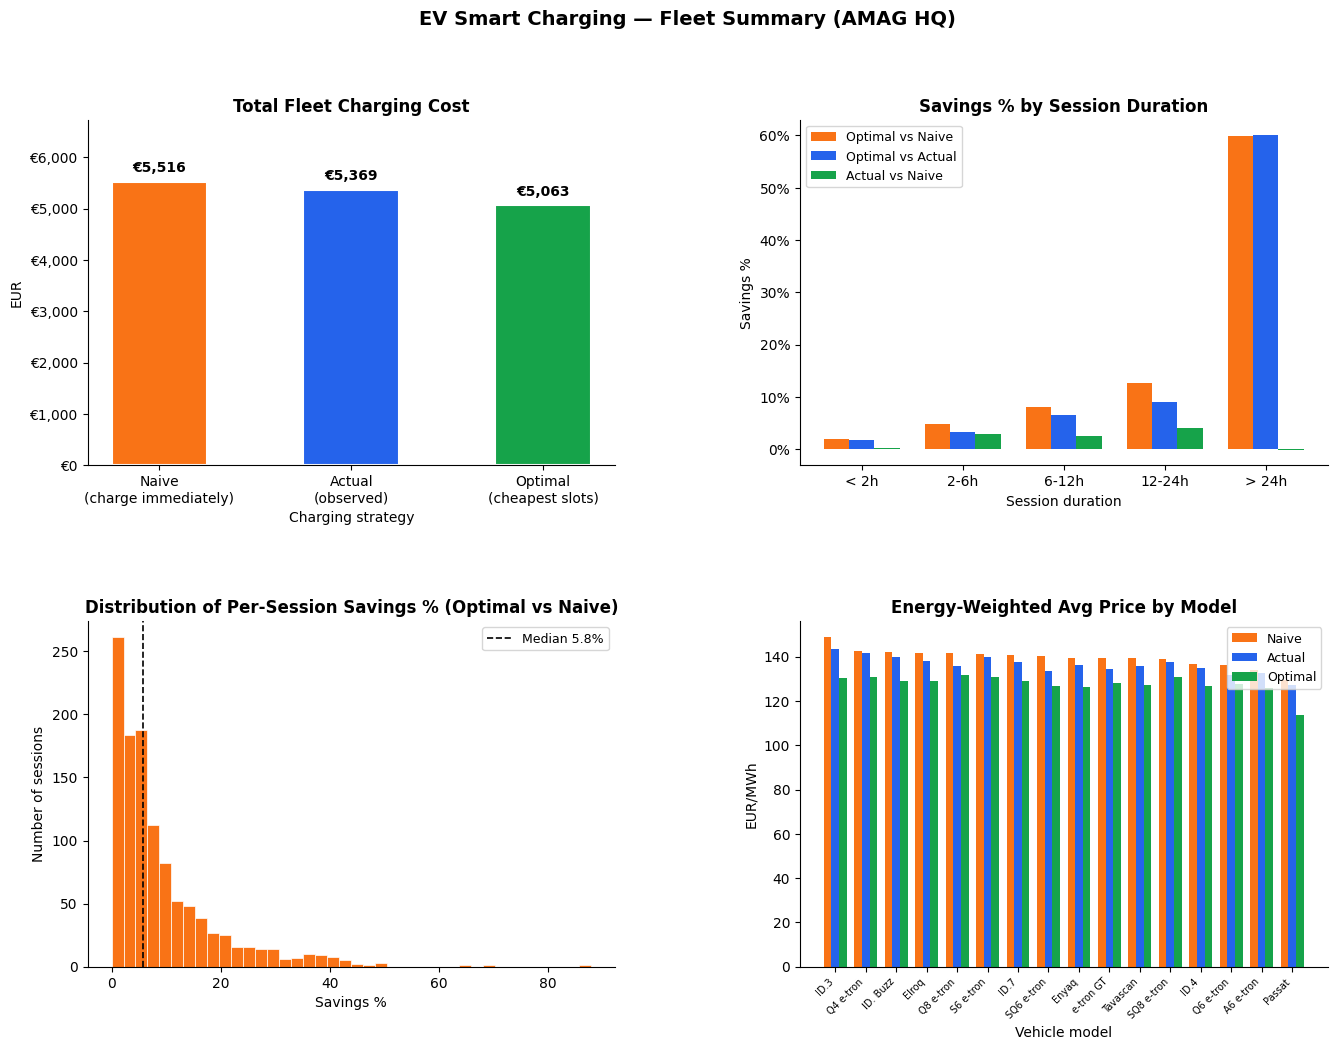

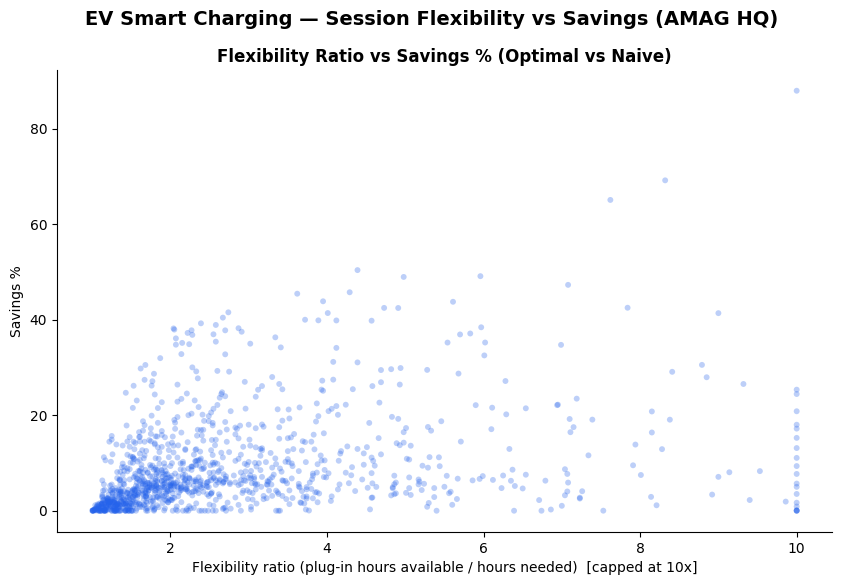

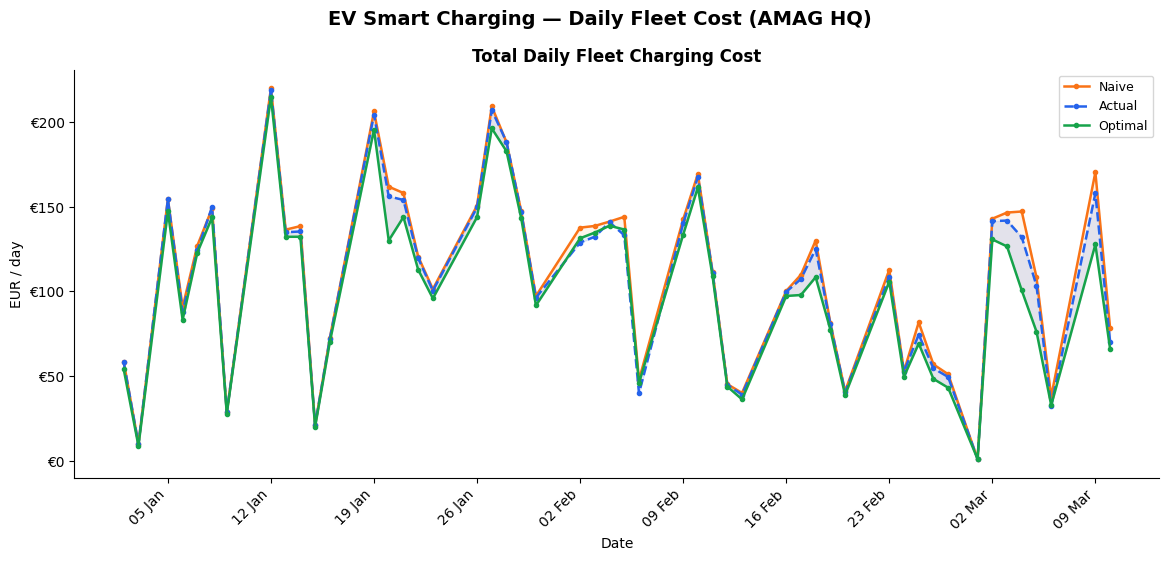

Figures saved: amag_fig1_summary.png  |  amag_fig2_flexibility.png  |  amag_fig3_daily_cost.png

  Helion HQ  (67 sessions)
  Total Vehicles.......................... 13
  Total Sessions.......................... 67
  Sessions With Actual Data............... 67
  Total Energy Kwh........................ 1929.0
  Total Naive Cost Eur.................... 263.67
  Total Actual Cost Eur................... 263.3
  Total Optimal Cost Eur.................. 238.74
  Total Savings Vs Naive Eur.............. 24.93
  Total Savings Vs Naive Pct.............. 9.5
  Total Savings Vs Actual Eur............. 24.57
  Total Savings Vs Actual Pct............. 9.3
  Avg Savings Per Session Eur............. 0.37
  Median Flexibility Ratio................ 1.86


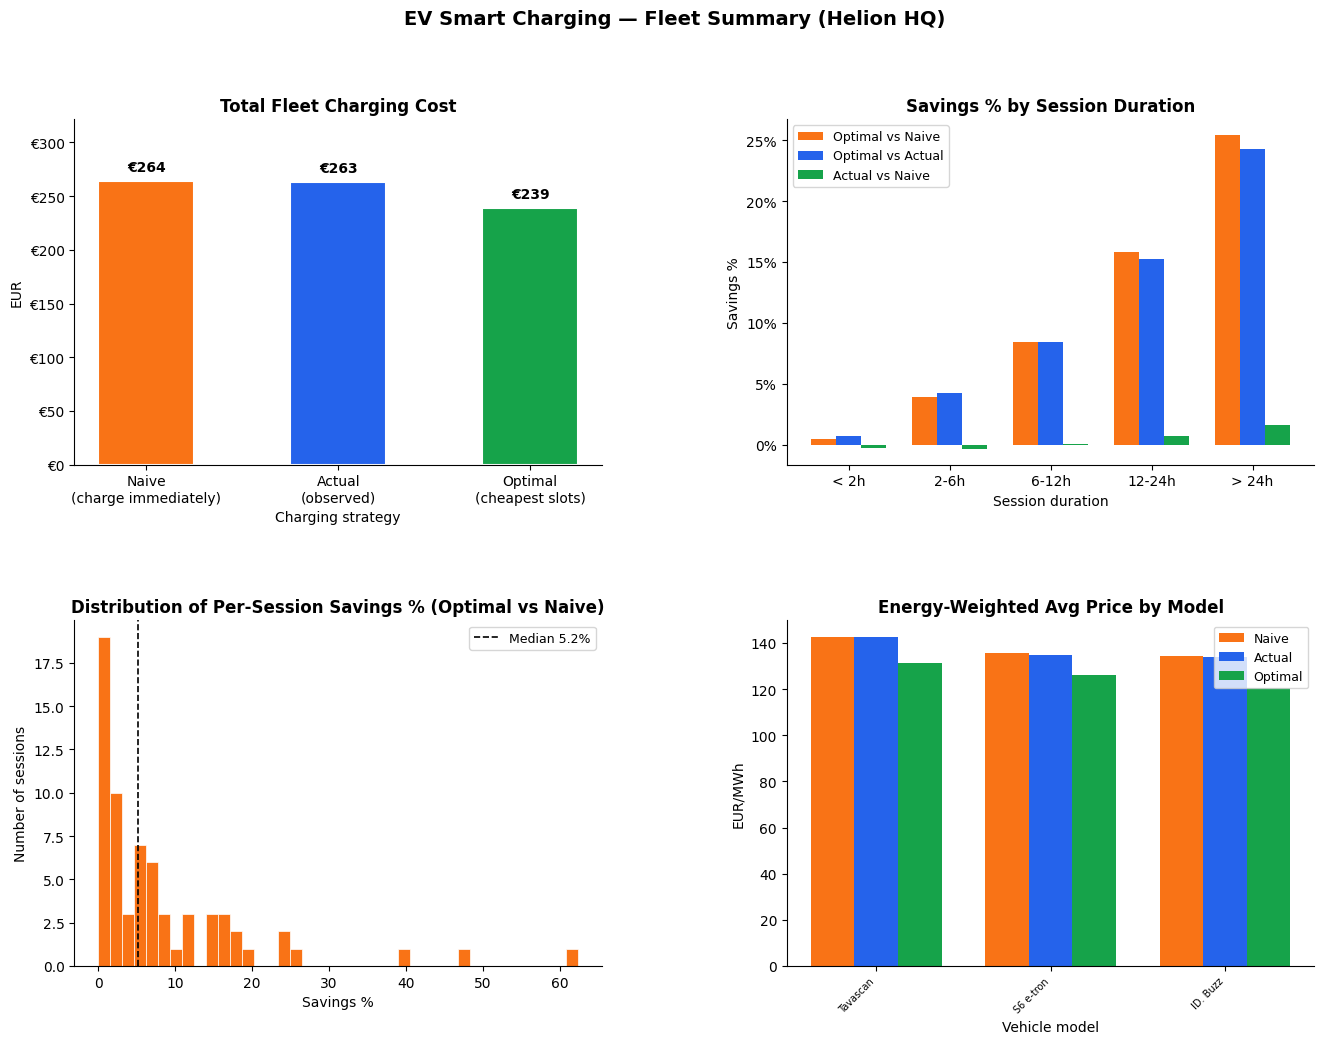

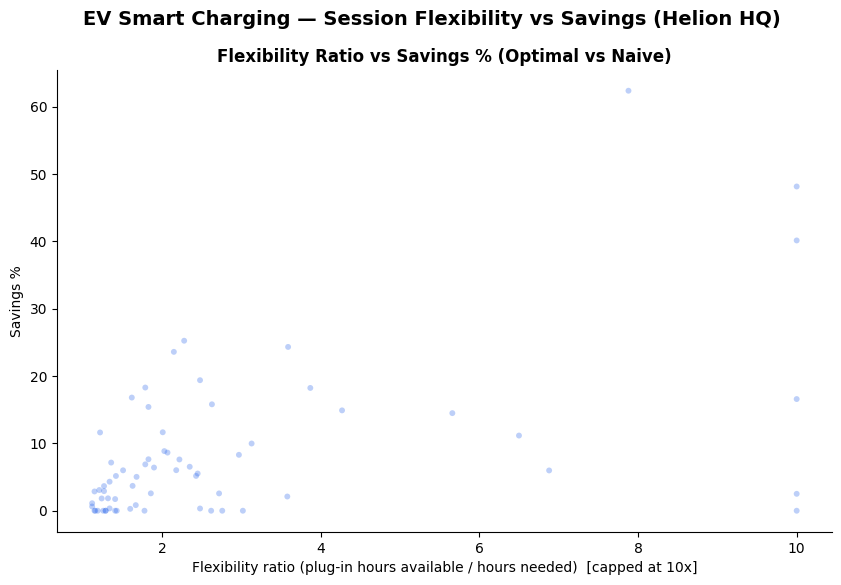

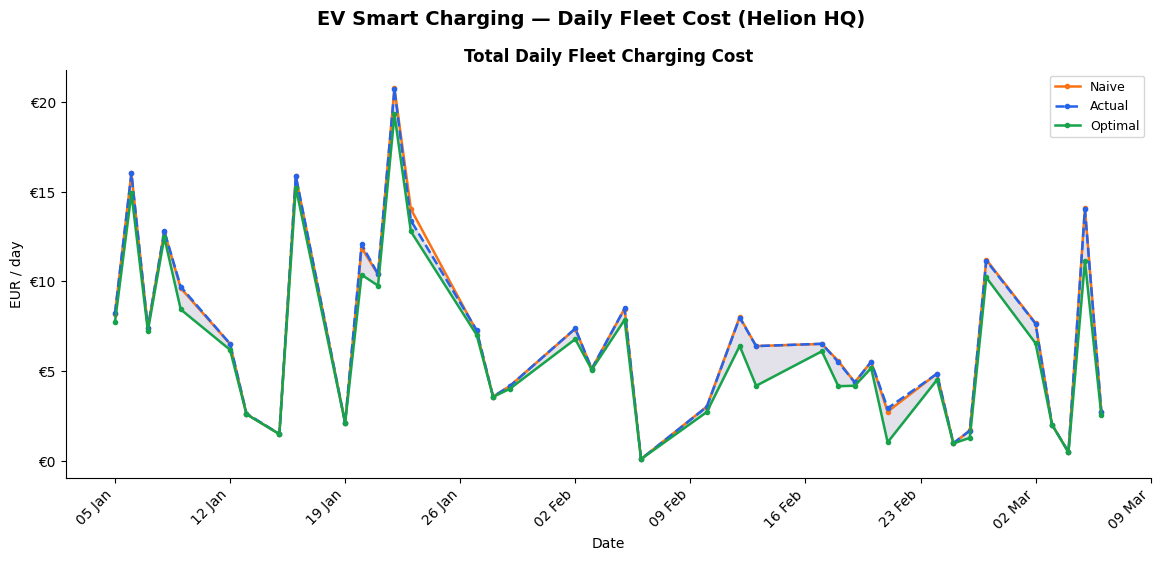

Figures saved: helion_fig1_summary.png  |  helion_fig2_flexibility.png  |  helion_fig3_daily_cost.png


In [7]:
BLUE   = "#2563EB"
ORANGE = "#F97316"
GREEN  = "#16A34A"

def fmt_eur(x, _):  return f"\u20ac{x:,.0f}"
def fmt_pct(x, _):  return f"{x:.0f}%"


def plot_financial_summary(df, site_name, fig_prefix):
    fleet    = analysis.fleet_summary(df)
    model_df = analysis.by_model(df)
    dur_df   = analysis.by_duration_bucket(df).copy()

    # ── Figure 1: Summary (2 x 2) ────────────────────────────────────────────
    fig1, axes = plt.subplots(2, 2, figsize=(16, 11))
    fig1.suptitle(f"EV Smart Charging \u2014 Fleet Summary ({site_name})", fontsize=14, fontweight="bold")
    fig1.subplots_adjust(hspace=0.45, wspace=0.35)

    # 1a. Fleet cost comparison
    ax = axes[0, 0]
    strategies = ["Naive\n(charge immediately)", "Actual\n(observed)", "Optimal\n(cheapest slots)"]
    costs      = [fleet["total_naive_cost_eur"], fleet["total_actual_cost_eur"], fleet["total_optimal_cost_eur"]]
    bars = ax.bar(strategies, costs, color=[ORANGE, BLUE, GREEN], width=0.5, edgecolor="white", linewidth=1.5)
    _offset = max(costs) * 0.025
    for bar, cost in zip(bars, costs):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + _offset,
                f"\u20ac{cost:,.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.set_title("Total Fleet Charging Cost", fontweight="bold")
    ax.set_xlabel("Charging strategy")
    ax.set_ylabel("EUR")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
    ax.set_ylim(0, max(costs) * 1.22)
    ax.spines[["top", "right"]].set_visible(False)

    # 1b. Savings % by duration bucket
    ax = axes[0, 1]
    buckets = dur_df["duration_bucket"].astype(str)
    x = np.arange(len(buckets))
    w = 0.25
    dur_df["actual_vs_naive_pct"] = np.where(
        dur_df["naive_cost_eur"] > 0,
        (dur_df["naive_cost_eur"] - dur_df["actual_cost_eur"]) / dur_df["naive_cost_eur"] * 100,
        0,
    )
    ax.bar(x - w, dur_df["savings_pct"],          w, color=ORANGE, label="Optimal vs Naive")
    ax.bar(x,     dur_df["savings_vs_actual_pct"], w, color=BLUE,   label="Optimal vs Actual")
    ax.bar(x + w, dur_df["actual_vs_naive_pct"],   w, color=GREEN,  label="Actual vs Naive")
    ax.set_xticks(x)
    ax.set_xticklabels(buckets)
    ax.set_title("Savings % by Session Duration", fontweight="bold")
    ax.set_xlabel("Session duration")
    ax.set_ylabel("Savings %")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_pct))
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    # 1c. Distribution of per-session savings %
    ax = axes[1, 0]
    pct_data = df["savings_pct"].dropna()
    ax.hist(pct_data, bins=40, color=ORANGE, edgecolor="white", linewidth=0.5)
    ax.axvline(pct_data.median(), color="black", linestyle="--", linewidth=1.2,
               label=f"Median {pct_data.median():.1f}%")
    ax.set_title("Distribution of Per-Session Savings % (Optimal vs Naive)", fontweight="bold")
    ax.set_xlabel("Savings %")
    ax.set_ylabel("Number of sessions")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    # 1d. Energy-weighted avg price by model
    ax = axes[1, 1]

    def wavg(grp, price_col, weight_col):
        w = grp[weight_col]
        return (grp[price_col] * w).sum() / w.sum() if w.sum() > 0 else float("nan")

    model_prices = (
        df.groupby("model")
        .apply(lambda g: pd.Series({
            "naive":   wavg(g, "naive_avg_price_eur_mwh",   "energy_needed_kwh"),
            "actual":  wavg(g, "actual_avg_price_eur_mwh",  "energy_needed_kwh"),
            "optimal": wavg(g, "optimal_avg_price_eur_mwh", "energy_needed_kwh"),
        }), include_groups=False)
        .sort_values("naive", ascending=False)
    )
    x = np.arange(len(model_prices))
    w_bar = 0.25
    ax.bar(x - w_bar, model_prices["naive"],   w_bar, color=ORANGE, label="Naive")
    ax.bar(x,         model_prices["actual"],  w_bar, color=BLUE,   label="Actual")
    ax.bar(x + w_bar, model_prices["optimal"], w_bar, color=GREEN,  label="Optimal")
    ax.set_xticks(x)
    ax.set_xticklabels(model_prices.index, rotation=45, ha="right", fontsize=7)
    ax.set_title("Energy-Weighted Avg Price by Model", fontweight="bold")
    ax.set_xlabel("Vehicle model")
    ax.set_ylabel("EUR/MWh")
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    out1 = f"{fig_prefix}_fig1_summary.png"
    fig1.savefig(out1, dpi=150, bbox_inches="tight")
    plt.show()

    # ── Figure 2: Flexibility ratio vs savings % ─────────────────────────────
    fig2, ax = plt.subplots(figsize=(10, 6))
    fig2.suptitle(f"EV Smart Charging \u2014 Session Flexibility vs Savings ({site_name})",
                  fontsize=14, fontweight="bold")
    flex = df["flexibility_ratio"].clip(upper=10)
    ax.scatter(flex, df["savings_pct"], alpha=0.3, s=18, c=BLUE, edgecolors="none")
    ax.set_title("Flexibility Ratio vs Savings % (Optimal vs Naive)", fontweight="bold")
    ax.set_xlabel("Flexibility ratio (plug-in hours available / hours needed)  [capped at 10x]")
    ax.set_ylabel("Savings %")
    ax.spines[["top", "right"]].set_visible(False)
    out2 = f"{fig_prefix}_fig2_flexibility.png"
    fig2.savefig(out2, dpi=150, bbox_inches="tight")
    plt.show()

    # ── Figure 3: Daily fleet charging cost ───────────────────────────────────
    fig3, ax = plt.subplots(figsize=(14, 6))
    fig3.suptitle(f"EV Smart Charging \u2014 Daily Fleet Cost ({site_name})",
                  fontsize=14, fontweight="bold")
    daily = (
        df
        .assign(date=pd.to_datetime(df["plug_in_time"]).dt.normalize())
        .groupby("date")
        .agg(naive=("naive_cost_eur", "sum"),
             actual=("actual_cost_eur", "sum"),
             optimal=("optimal_cost_eur", "sum"))
        .reset_index()
    )
    ax.plot(daily["date"], daily["naive"],   color=ORANGE, linewidth=1.8, label="Naive",
            marker="o", markersize=3)
    ax.plot(daily["date"], daily["actual"],  color=BLUE,   linewidth=1.8, label="Actual",
            marker="o", markersize=3, linestyle="--")
    ax.plot(daily["date"], daily["optimal"], color=GREEN,  linewidth=1.8, label="Optimal",
            marker="o", markersize=3)
    ax.fill_between(daily["date"], daily["optimal"], daily["naive"],  alpha=0.08, color=ORANGE)
    ax.fill_between(daily["date"], daily["optimal"], daily["actual"], alpha=0.12, color=BLUE)
    ax.set_title("Total Daily Fleet Charging Cost", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("EUR / day")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_eur))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
    fig3.autofmt_xdate(rotation=45)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
    out3 = f"{fig_prefix}_fig3_daily_cost.png"
    fig3.savefig(out3, dpi=150, bbox_inches="tight")
    plt.show()

    print(f"Figures saved: {out1}  |  {out2}  |  {out3}")


# ── Run per-site ──────────────────────────────────────────────────────────────
for _site_df, _site_name, _prefix in [
    (amag_df,   "AMAG HQ",   "amag"),
    (helion_df, "Helion HQ", "helion"),
]:
    print("\n" + "=" * 70)
    print(f"  {_site_name}  ({len(_site_df):,} sessions)")
    print("=" * 70)
    _fleet = analysis.fleet_summary(_site_df)
    for k, v in _fleet.items():
        print(f"  {k.replace('_', ' ').title():.<40} {v}")
    plot_financial_summary(_site_df, _site_name, _prefix)


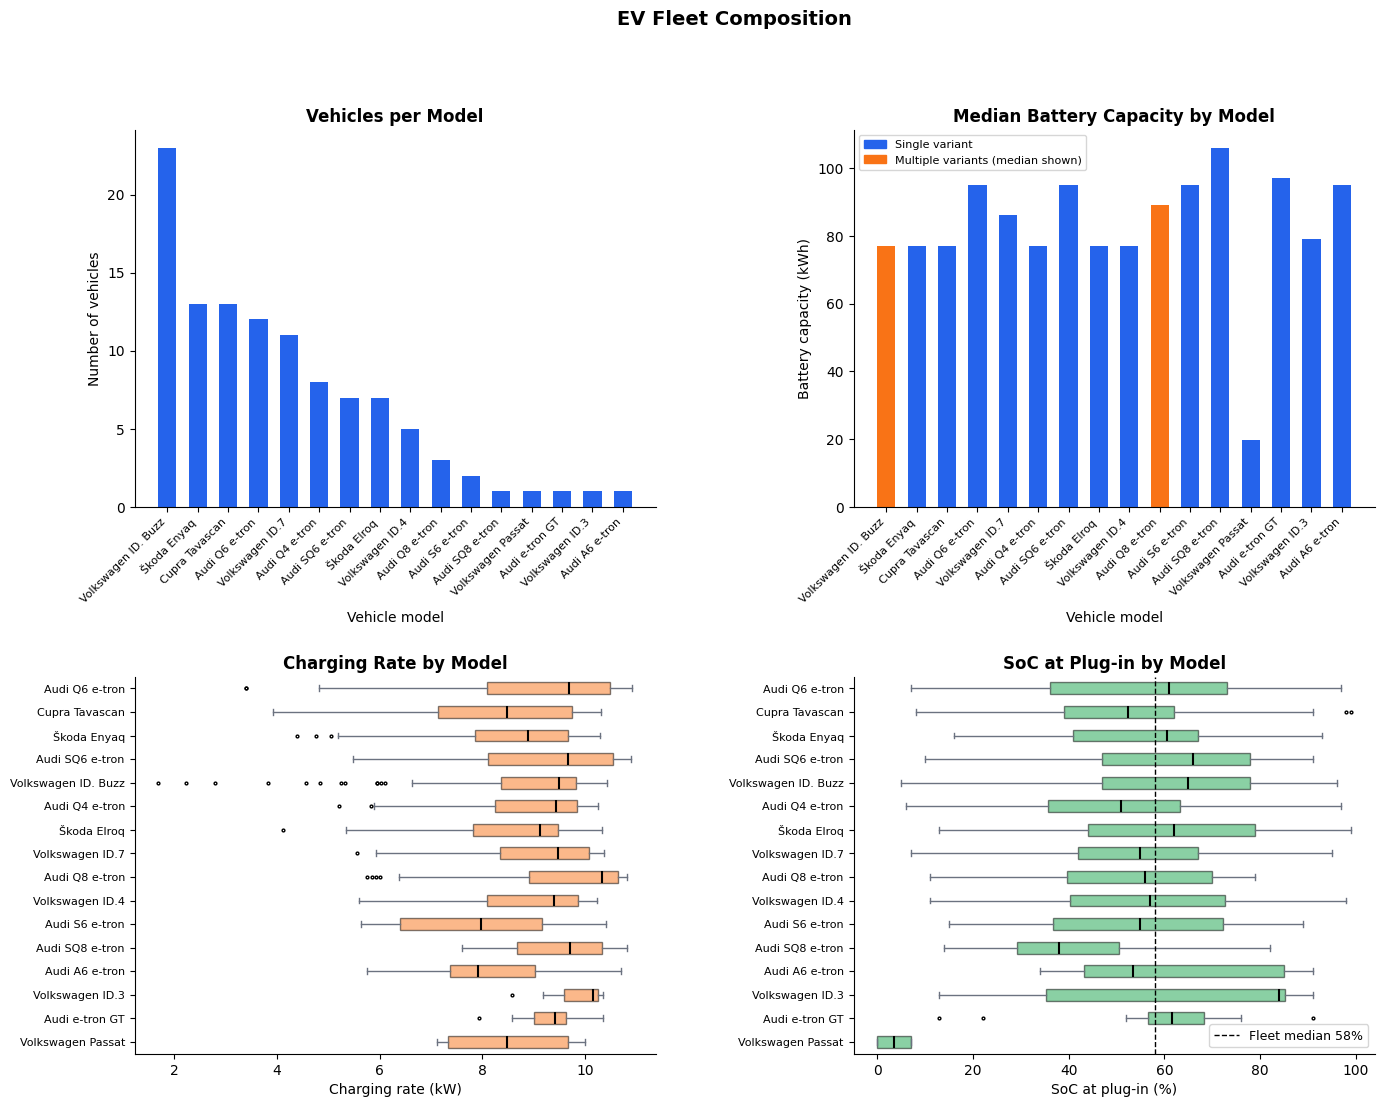

Saved: fig_fleet_composition.png


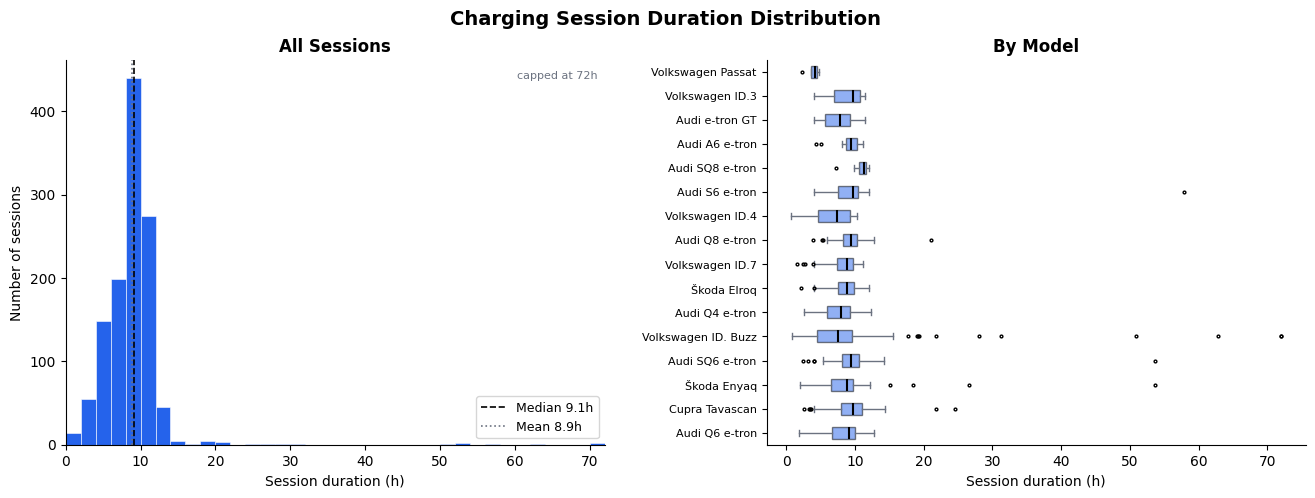

Saved: fig_session_duration.png


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
# FLEET COMPOSITION — vehicle & session characteristics
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

BLUE   = "#2563EB"
ORANGE = "#F97316"
GREEN  = "#16A34A"
GREY   = "#6B7280"

df = results_df.copy()
df["display_model"] = df["brand"] + " " + df["model"]

# Order models by session count ascending (for horizontal box plots)
model_order = df.groupby("display_model")["vehicle_id"].count().sort_values(ascending=True).index.tolist()
df["display_model"] = pd.Categorical(df["display_model"], categories=model_order, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("EV Fleet Composition", fontsize=14, fontweight="bold")
fig.subplots_adjust(hspace=0.45, wspace=0.38)

# ── A: Vehicles per model ────────────────────────────────────────────────────
ax = axes[0, 0]
vehicles_per_model = df.groupby("display_model", observed=True)["vehicle_id"].nunique()
model_order_desc = vehicles_per_model.sort_values(ascending=False).index.tolist()
x = np.arange(len(model_order_desc))
ax.bar(x, vehicles_per_model.reindex(model_order_desc).values, color=BLUE, width=0.6)
ax.set_xticks(x)
ax.set_xticklabels(model_order_desc, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Number of vehicles")
ax.set_xlabel("Vehicle model")
ax.set_title("Vehicles per Model", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

# ── B: Battery capacity by model (median) ────────────────────────────────────
ax = axes[0, 1]
cap_median = df.groupby("display_model", observed=True)["battery_capacity_kwh"].median().reindex(model_order_desc)
cap_std    = df.groupby("display_model", observed=True)["battery_capacity_kwh"].std().reindex(model_order_desc).fillna(0)
colors_b   = [ORANGE if s > 2 else BLUE for s in cap_std]
x = np.arange(len(model_order_desc))
ax.bar(x, cap_median.values, color=colors_b, width=0.6)
ax.set_xticks(x)
ax.set_xticklabels(model_order_desc, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Battery capacity (kWh)")
ax.set_xlabel("Vehicle model")
ax.set_title("Median Battery Capacity by Model", fontweight="bold")
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="Single variant"),
                   Patch(color=ORANGE, label="Multiple variants (median shown)")],
          fontsize=8)
ax.spines[["top", "right"]].set_visible(False)

# ── C: Charging rate by model ─────────────────────────────────────────────────
ax = axes[1, 0]
rate_by_model = [df[df["display_model"] == m]["charge_rate_kw"].dropna().values
                 for m in model_order]
ax.boxplot(rate_by_model, vert=False, patch_artist=True,
           boxprops=dict(facecolor=ORANGE, alpha=0.5),
           medianprops=dict(color="black", linewidth=1.5),
           whiskerprops=dict(color=GREY), capprops=dict(color=GREY),
           flierprops=dict(marker=".", markersize=4, color=GREY))
ax.set_yticks(range(1, len(model_order) + 1))
ax.set_yticklabels(model_order, fontsize=8)
ax.set_xlabel("Charging rate (kW)")
ax.set_title("Charging Rate by Model", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

# ── D: SoC at plug-in distribution ───────────────────────────────────────────
ax = axes[1, 1]
soc_by_model = [df[df["display_model"] == m]["soc_start_pct"].dropna().values
                for m in model_order]
ax.boxplot(soc_by_model, vert=False, patch_artist=True,
           boxprops=dict(facecolor=GREEN, alpha=0.5),
           medianprops=dict(color="black", linewidth=1.5),
           whiskerprops=dict(color=GREY), capprops=dict(color=GREY),
           flierprops=dict(marker=".", markersize=4, color=GREY))
ax.set_yticks(range(1, len(model_order) + 1))
ax.set_yticklabels(model_order, fontsize=8)
ax.set_xlabel("SoC at plug-in (%)")
ax.set_title("SoC at Plug-in by Model", fontweight="bold")
ax.axvline(df["soc_start_pct"].median(), color="black", linestyle="--",
           linewidth=1, label=f"Fleet median {df['soc_start_pct'].median():.0f}%")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)

fig.savefig("fig_fleet_composition.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_fleet_composition.png")

# ═══════════════════════════════════════════════════════════════════════════════
# SESSION DURATION DISTRIBUTION
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

BLUE  = "#2563EB"
GREY  = "#6B7280"

df = results_df.copy()
df["display_model"] = df["brand"] + " " + df["model"]
model_order = df.groupby("display_model")["vehicle_id"].count().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Charging Session Duration Distribution", fontsize=14, fontweight="bold")
fig.subplots_adjust(wspace=0.3)

# ── Left: fleet-wide histogram ───────────────────────────────────────────────
ax = axes[0]
cap = 72  # cap display at 72h to avoid long tail distorting the plot
data = df["hours_available"].clip(upper=cap)
bins = np.arange(0, cap + 2, 2)
ax.hist(data, bins=bins, color=BLUE, edgecolor="white", linewidth=0.4)
ax.axvline(df["hours_available"].median(), color="black", linestyle="--", linewidth=1.2,
           label=f"Median {df['hours_available'].median():.1f}h")
ax.axvline(df["hours_available"].mean(), color=GREY, linestyle=":", linewidth=1.2,
           label=f"Mean {df['hours_available'].mean():.1f}h")
ax.set_xlabel("Session duration (h)")
ax.set_ylabel("Number of sessions")
ax.set_title("All Sessions", fontweight="bold")
ax.legend(fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
if data.max() >= cap:
    ax.set_xlim(0, cap)
    ax.text(cap - 1, ax.get_ylim()[1] * 0.95, f"capped at {cap}h",
            ha="right", fontsize=8, color=GREY)

# ── Right: box plot by model ──────────────────────────────────────────────────
ax = axes[1]
dur_by_model = [df[df["display_model"] == m]["hours_available"].clip(upper=cap).values
                for m in model_order]
ax.boxplot(dur_by_model, vert=False, patch_artist=True,
           boxprops=dict(facecolor=BLUE, alpha=0.5),
           medianprops=dict(color="black", linewidth=1.5),
           whiskerprops=dict(color=GREY), capprops=dict(color=GREY),
           flierprops=dict(marker=".", markersize=4, color=GREY))
ax.set_yticks(range(1, len(model_order) + 1))
ax.set_yticklabels(model_order, fontsize=8)
ax.set_xlabel("Session duration (h)")
ax.set_title("By Model", fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)

fig.savefig("fig_session_duration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: fig_session_duration.png")

